## Biomarker analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('C:/Users/nva_kist/Desktop/minsun/KIST/BioMarker/refined_dataset.xlsx')

In [2]:
df.head()

,ID,Sex,Age,BMI,AST,ALT,ALP,Bilirubin,Protein,Albumin,...,CD11b.1,HLADR.1,NK.1,NKT1.1,T.1,Transitional B.1,Memory B.1,Early Plasma B .1,Plasma B.1,ABC.1
0,KUMC039,F,66,20.14,40,36,71.0,0.53,7.0,4.6,...,7435.848212,2325.931126,3373.697270,949.023785,69240.336501,642.033790,13.725188,8.235113,79.301086,19.215263
1,KUMC040,M,78,24.54,36,26,75.0,1.32,7.5,4.3,...,12149.508912,7729.607360,3800.419287,1506.942813,109202.890471,39948.855589,159.468308,98.134343,122.667929,482.493855
2,KUMC041,M,47,24.89,22,13,65.0,0.41,6.8,4.6,...,1994.524906,645.388438,9037.154587,719.196158,11731.994607,197.499161,0.000000,5.100972,12.011262,3.378849
3,KUMC042,F,66,25.29,28,16,81.0,0.72,6.8,4.5,...,3316.743565,1284.478895,980.784272,515.782998,43727.047026,526.615437,3.993833,3.993833,21.909028,11.924445
4,KUMC045,M,66,21.59,28,21,51.0,1.10,6.9,4.2,...,4241.189672,1624.390456,2532.864146,2073.689944,57752.264953,4131.331010,46.752821,31.917791,128.570258,123.625248


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 75 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 44 non-null     object 
 1   Sex                44 non-null     object 
 2   Age                44 non-null     int64  
 3   BMI                44 non-null     float64
 4   AST                44 non-null     int64  
 5   ALT                44 non-null     int64  
 6   ALP                43 non-null     float64
 7   Bilirubin          44 non-null     float64
 8   Protein            22 non-null     float64
 9   Albumin            44 non-null     float64
 10  PT                 22 non-null     float64
 11  APTT               22 non-null     float64
 12  Cholesterol        42 non-null     float64
 13  TG                 22 non-null     float64
 14  LDL                22 non-null     float64
 15  HDL                22 non-null     float64
 16  R_Glucose          22 non-nu

In [4]:
df.columns

Index(['ID', 'Sex', 'Age', 'BMI', 'AST', 'ALT', 'ALP', 'Bilirubin', 'Protein',
       'Albumin', 'PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL', 'R_Glucose',
       'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl', 'Amylase',
       'CRP', 'Unnamed: 25', 'B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T',
       'Unnamed: 32', 'NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%', 'Unnamed: 38',
       'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'Unnamed: 43', 'CD20T',
       'Unnamed: 45', 'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm',
       'CD4grzk', 'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Unnamed: 56',
       'Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC',
       'Unnamed: 62', 'Total', 'B.1', 'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1',
       'T.1', 'Transitional B.1', 'Memory B.1', 'Early Plasma B .1',
       'Plasma B.1', 'ABC.1'],
      dtype='object')

In [3]:
cols = ['B',	'CD11b',	'HLADR',	'NK',	'NKT1',	'T',
        'NKT2',	'MAIT'	,'gd1T',	'gd2T',	'ConvT%',
'CD8+T',	'CD4+T',	'CD8+Treg',	'CD4+Treg',	
'CD20T',
'CD4trm',	'CD8trm',	'MAITtrm',	'GD1Ttrm',	'GD2Ttrm',	'CD4grzk',	
'CD8grzk',	'MAITgrzK',	'GD1TgrzK',	'GD2TgrzK',
'Transitional B',	'Memory B',	'Early Plasma B ','Plasma B',	'ABC'
]

# % 제거하기
df[cols] = (df[cols]
            .replace(r'^\s*$', pd.NA, regex=True) 
            .replace({',': ''}, regex=True)
            .replace({'%': ''}, regex=True)   
            .apply(pd.to_numeric, errors='coerce')
            *100)                                       
# unnamed 인 column 제거 
df = df.loc[:, ~df.columns.str.contains(r'^Unnamed')]


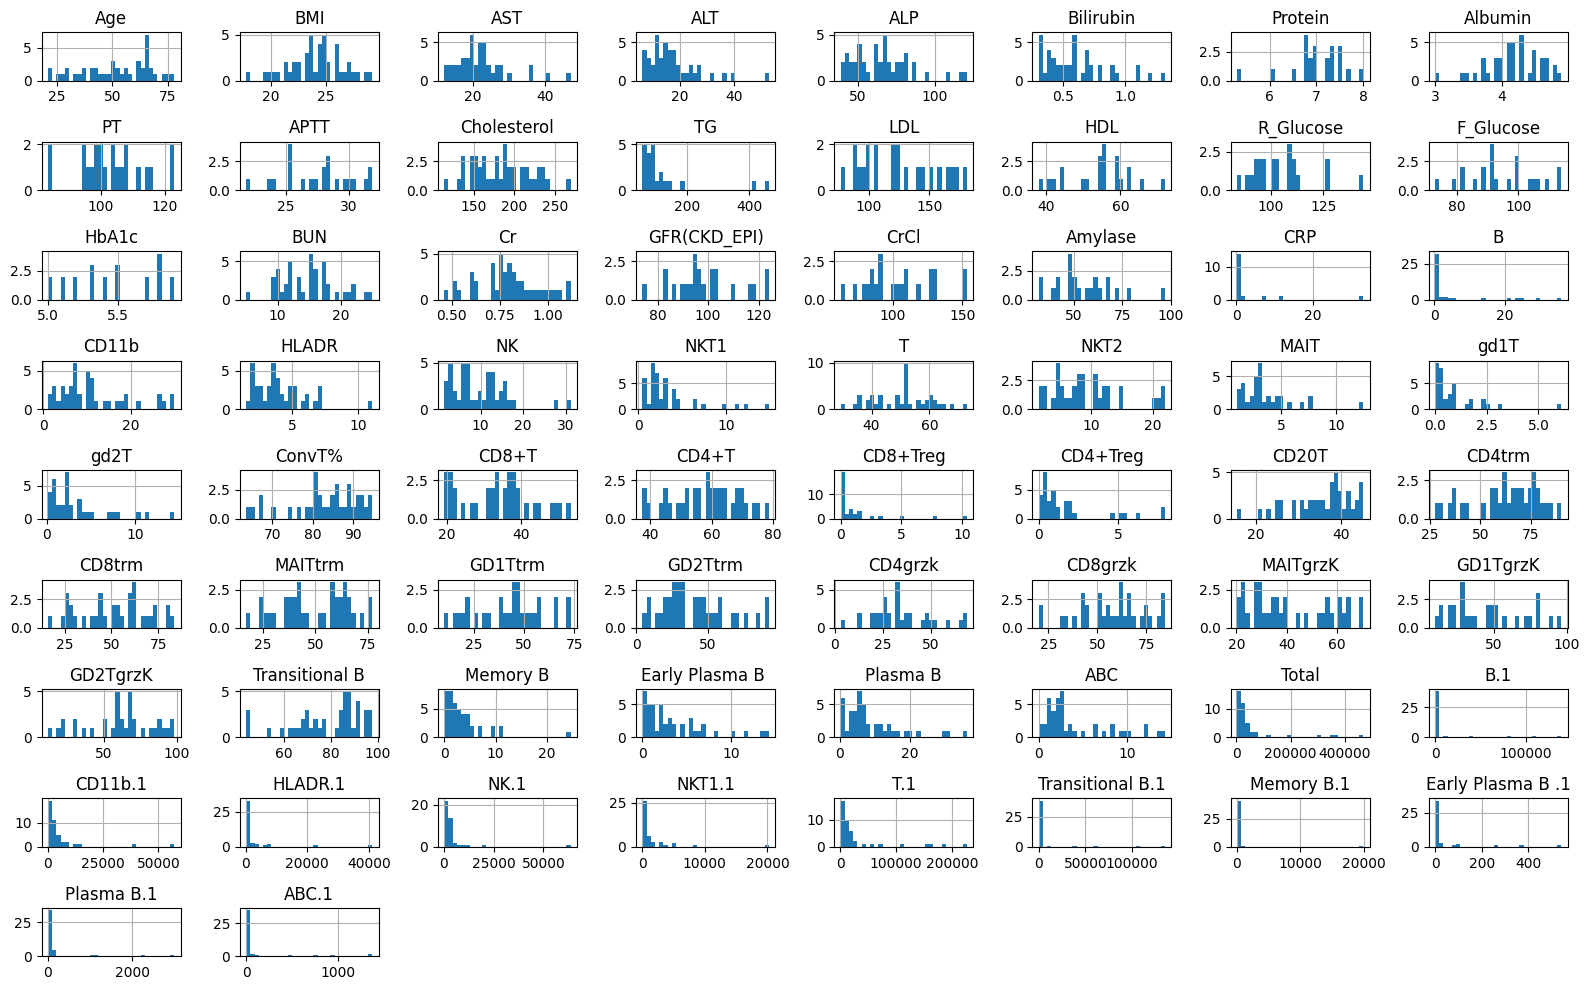

In [6]:
# 데이터 분포 확인
df.hist(bins=30, figsize=(16,10)); plt.tight_layout(); plt.show()

## Task1 - 나이 & 면역세포

 ###  Partial correlation analysis

In [7]:
import seaborn as sns
import pingouin as pg

### pan% & age

In [8]:
columns = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']

for c in columns:
   print('result of age and ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI']))
   print("_________________________________________________")
   

result of age and  B 
           n         r          CI95%     p-val
pearson  44  0.132268  [-0.18, 0.42]  0.397829
_________________________________________________
result of age and  CD11b 
           n         r          CI95%     p-val
pearson  44 -0.253556  [-0.51, 0.05]  0.100876
_________________________________________________
result of age and  HLADR 
           n         r           CI95%     p-val
pearson  44 -0.305647  [-0.56, -0.01]  0.046241
_________________________________________________
result of age and  NK 
           n         r         CI95%     p-val
pearson  44 -0.231679  [-0.5, 0.07]  0.134947
_________________________________________________
result of age and  NKT1 
           n         r          CI95%     p-val
pearson  44 -0.138999  [-0.42, 0.17]  0.374033
_________________________________________________
result of age and  T 
           n         r         CI95%     p-val
pearson  44  0.353325  [0.06, 0.59]  0.020117
______________________________________

#### Change Sex to binary, then set cofounder as sex + BMI

In [9]:
#Sex column 0,1로 바꾸기
df['Sex_01'] = df['Sex'].map({'F': 0, 'M': 1})
print(df['Sex_01'].head())

0    0
1    1
2    1
3    0
4    1
Name: Sex_01, dtype: int64


In [10]:
# BMI + Sex
columns = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']

for c in columns:
   print('result of age and ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI', 'Sex_01']))
   print("_________________________________________________")

result of age and  B 
           n        r          CI95%     p-val
pearson  44  0.10035  [-0.21, 0.39]  0.527183
_________________________________________________
result of age and  CD11b 
           n         r          CI95%     p-val
pearson  44 -0.262178  [-0.52, 0.05]  0.093481
_________________________________________________
result of age and  HLADR 
           n         r           CI95%    p-val
pearson  44 -0.323769  [-0.57, -0.02]  0.03647
_________________________________________________
result of age and  NK 
           n         r          CI95%     p-val
pearson  44 -0.202946  [-0.48, 0.11]  0.197393
_________________________________________________
result of age and  NKT1 
           n         r          CI95%     p-val
pearson  44 -0.120495  [-0.41, 0.19]  0.447189
_________________________________________________
result of age and  T 
           n         r         CI95%     p-val
pearson  44  0.348037  [0.05, 0.59]  0.023908
________________________________________

### Partial Least Squares Regression

In [11]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

X = df[['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']]
y = df[['Age']]

# Standardization
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

max_comp = min(X_scaled.shape[1], X_scaled.shape[0]-1)  
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_list = []
for n in range(1, max_comp+1):
    rmses = []
    for tr, te in kf.split(X_scaled):
        pls_cv = PLSRegression(n_components=n)
        pls_cv.fit(X_scaled[tr], y_scaled[tr])
        pred = pls_cv.predict(X_scaled[te])
        rmses.append(np.sqrt(mean_squared_error(y_scaled[te], pred)))
    rmse_list.append(np.mean(rmses))

best_n = int(np.argmin(rmse_list) + 1)
print("best n_components =", best_n)

best n_components = 1


In [13]:
pls = PLSRegression(n_components=1)
pls.fit(X_scaled, y_scaled)

# 예측
y_pred = pls.predict(X_scaled)

# Correlation 계산
r, p = pearsonr(y_scaled[:, 0], y_pred[:, 0])
print(f"PLSR Component 1과 Age의 correlation: {r:.4f} (p={p:.4f})")

# 변수 중요도=> Loadings
X_cols =['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']
loadings = pd.Series(pls.x_loadings_[:, 0], index=X_cols).sort_values(key=abs, ascending=False)

print("\n=== PLSR Loadings  ===")
print(loadings)

# Weights 확인 
weights = pd.Series(pls.x_weights_[:, 0], index=X_cols).sort_values(key=abs, ascending=False)
print("\n=== PLSR Weights ===")
print(weights)

PLSR Component 1과 Age의 correlation: 0.4104 (p=0.0057)

=== PLSR Loadings  ===
T        0.566311
HLADR   -0.496694
CD11b   -0.442161
NK      -0.364647
B        0.281287
NKT1    -0.181536
dtype: float64

=== PLSR Weights ===
T        0.566622
HLADR   -0.508744
CD11b   -0.403101
NK      -0.388593
NKT1    -0.234467
B        0.227266
dtype: float64


#### Permutation test

In [14]:
from sklearn.model_selection import permutation_test_score

pls = PLSRegression(n_components=1)

score, perm_scores, p_perm = permutation_test_score(
    pls,
    X_scaled,
    y_scaled.ravel(),
    scoring="r2",
    n_permutations=1000,
    random_state=42
)

print(f"CV R2: {score:.4f}")
print(f"Permutation test p-value: {p_perm:.4f}")

CV R2: -0.2355
Permutation test p-value: 0.2557


#### T 소분류- NKT2	MAIT	gd1T	gd2T	ConvT% & Age

결측치 처리 

In [15]:
# 결측치 8명 -> 다중대체법(Multiple Imputation)적용
from impyute.imputation.cs import mice
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

<Axes: >

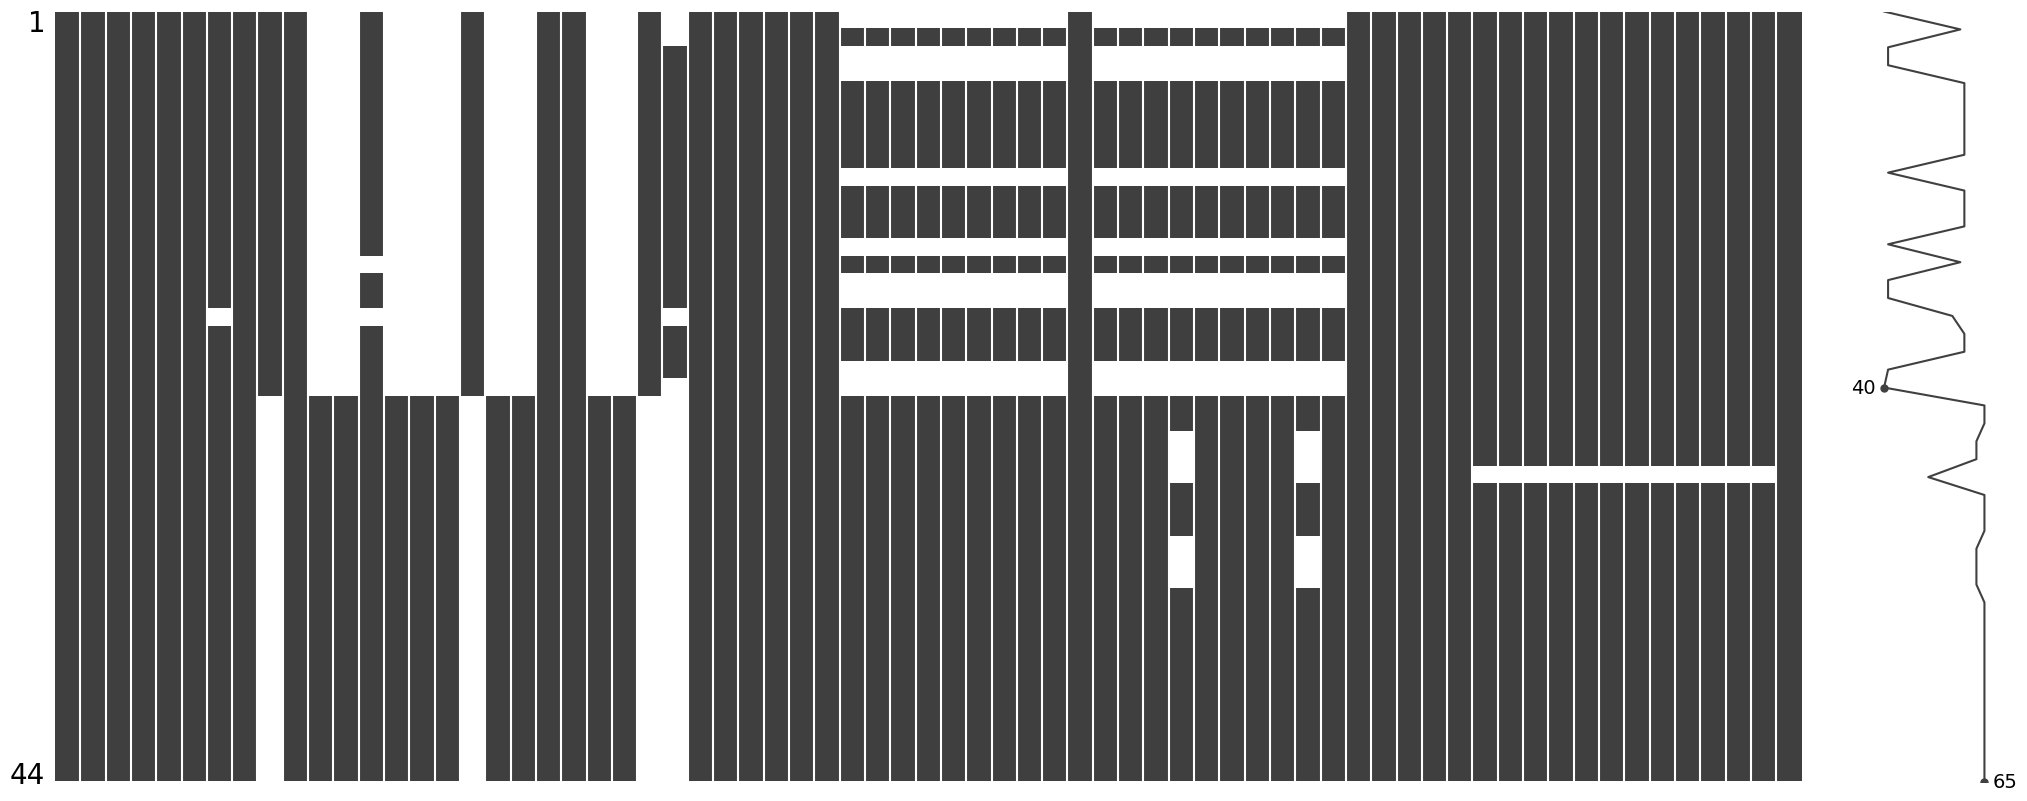

In [16]:
import missingno as msno
msno.matrix(df)

### 결측치 처리

1. Multiple Imputation (MICE)

In [17]:
df.columns

Index(['ID', 'Sex', 'Age', 'BMI', 'AST', 'ALT', 'ALP', 'Bilirubin', 'Protein',
       'Albumin', 'PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL', 'R_Glucose',
       'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl', 'Amylase',
       'CRP', 'B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC', 'Total', 'B.1',
       'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1', 'T.1', 'Transitional B.1',
       'Memory B.1', 'Early Plasma B .1', 'Plasma B.1', 'ABC.1', 'Sex_01'],
      dtype='object')

In [19]:
# 최적화된 결측치 처리 방법
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import miceforest as mf

impute_cols = ['NKT2','MAIT','gd1T','gd2T','ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T', 'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk', 'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', ]
keep_cols_mice = ['B.1', 'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1', 'T.1',
                  'Transitional B.1', 'Memory B.1', 'Early Plasma B .1',
                  'Plasma B.1', 'ABC.1', 'Age', 'BMI','Sex_01', 'Total']

# 사용 가능한 컬럼만 선택
available_cols_mice = [col for col in keep_cols_mice if col in df.columns]
use_cols_mice = available_cols_mice + impute_cols
df_sub_mice = df[use_cols_mice].copy()

kernel_mice = mf.ImputationKernel(
    data=df_sub_mice,
    num_datasets=5,
    save_all_iterations_data=True,
    random_state=42
)
kernel_mice.mice(iterations=10)

df_mice = df.copy()
df_mice[impute_cols] = kernel_mice.complete_data(dataset=0)[impute_cols]


In [20]:
# 5개의 mice 결과 dataset의 평균 - 새로운 데이터셋 df_mean으로 저장
m = kernel_mice.num_datasets
stack = np.stack([
    kernel_mice.complete_data(dataset=i)[impute_cols].to_numpy()
    for i in range(m)
], axis=0)

df_mean = df.copy()
df_mean[impute_cols] = stack.mean(axis=0)
df_mean['NKT2'].head()

0     3.072
1     4.810
2    14.466
3     3.910
4     2.630
Name: NKT2, dtype: float64

2. 결측치 삭제

In [21]:
cols = ["NKT2", "MAIT", "gd1T", "gd2T", "ConvT%"]
df_del = df.dropna(subset=cols)
df_del["NKT2"].head()

1     4.81
4     2.63
5    10.70
6     5.15
7     6.21
Name: NKT2, dtype: float64

In [22]:
# 결과: df_mean, df_del이 결측치 처리한 데이터

In [23]:
df_del.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 1 to 43
Data columns (total 69 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 35 non-null     object 
 1   Sex                35 non-null     object 
 2   Age                35 non-null     int64  
 3   BMI                35 non-null     float64
 4   AST                35 non-null     int64  
 5   ALT                35 non-null     int64  
 6   ALP                34 non-null     float64
 7   Bilirubin          35 non-null     float64
 8   Protein            13 non-null     float64
 9   Albumin            35 non-null     float64
 10  PT                 22 non-null     float64
 11  APTT               22 non-null     float64
 12  Cholesterol        33 non-null     float64
 13  TG                 22 non-null     float64
 14  LDL                22 non-null     float64
 15  HDL                22 non-null     float64
 16  R_Glucose          13 non-null   

### T세포 소분류 & Age 사이 Partial correlation anlaysis

In [24]:
# df_del + BMI
columns = ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_del, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

result of age &  NKT2 
           n         r          CI95%     p-val
pearson  35 -0.421784  [-0.67, -0.1]  0.012971
_________________________________________________
result of age &  MAIT 
           n         r         CI95%     p-val
pearson  35 -0.190535  [-0.5, 0.16]  0.280422
_________________________________________________
result of age &  gd1T 
           n         r          CI95%     p-val
pearson  35 -0.276126  [-0.56, 0.07]  0.113932
_________________________________________________
result of age &  gd2T 
           n         r          CI95%     p-val
pearson  35 -0.282655  [-0.57, 0.06]  0.105292
_________________________________________________
result of age &  ConvT% 
           n         r         CI95%     p-val
pearson  35  0.491285  [0.18, 0.71]  0.003173
_________________________________________________


In [25]:
# df_del + BMI + sex
columns = ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_del, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

result of age &  NKT2 
           n        r           CI95%     p-val
pearson  35 -0.42205  [-0.67, -0.09]  0.014424
_________________________________________________
result of age &  MAIT 
           n         r          CI95%     p-val
pearson  35 -0.198911  [-0.51, 0.15]  0.267115
_________________________________________________
result of age &  gd1T 
           n         r          CI95%     p-val
pearson  35 -0.276646  [-0.57, 0.07]  0.119108
_________________________________________________
result of age &  gd2T 
           n         r          CI95%     p-val
pearson  35 -0.286393  [-0.57, 0.06]  0.106134
_________________________________________________
result of age &  ConvT% 
           n         r         CI95%     p-val
pearson  35  0.495951  [0.18, 0.72]  0.003334
_________________________________________________


In [26]:
# df_mean + BMI
columns = ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mean, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

result of age &  NKT2 
           n         r           CI95%     p-val
pearson  44 -0.464962  [-0.67, -0.19]  0.001681
_________________________________________________
result of age &  MAIT 
           n         r          CI95%     p-val
pearson  44 -0.193604  [-0.47, 0.11]  0.213519
_________________________________________________
result of age &  gd1T 
           n         r          CI95%     p-val
pearson  44 -0.279964  [-0.54, 0.02]  0.069017
_________________________________________________
result of age &  gd2T 
           n        r           CI95%    p-val
pearson  44 -0.30717  [-0.56, -0.01]  0.04511
_________________________________________________
result of age &  ConvT% 
           n         r         CI95%     p-val
pearson  44  0.529995  [0.27, 0.72]  0.000257
_________________________________________________


In [27]:
# df_mean + BMI + sex
columns = ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mean, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

result of age &  NKT2 
           n         r           CI95%     p-val
pearson  44 -0.458337  [-0.67, -0.18]  0.002269
_________________________________________________
result of age &  MAIT 
           n         r         CI95%     p-val
pearson  44 -0.211811  [-0.48, 0.1]  0.178108
_________________________________________________
result of age &  gd1T 
           n         r          CI95%     p-val
pearson  44 -0.276251  [-0.54, 0.03]  0.076573
_________________________________________________
result of age &  gd2T 
           n         r           CI95%     p-val
pearson  44 -0.315421  [-0.57, -0.01]  0.041877
_________________________________________________
result of age &  ConvT% 
           n         r         CI95%     p-val
pearson  44  0.528249  [0.27, 0.72]  0.000324
_________________________________________________


### CD20T & age partial correlation analysis

In [28]:
columns = ['CD20T']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_del, x='Age', y= c , covar=['BMI'], method='spearman'))
   print("_________________________________________________")
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

result of age &  CD20T 
            n         r         CI95%     p-val
spearman  35  0.152191  [-0.2, 0.47]  0.390203
_________________________________________________
result of age &  CD20T 
           n         r          CI95%     p-val
pearson  44  0.220541  [-0.09, 0.49]  0.155277
_________________________________________________


### B cell 소분류 & age partial correlation analysis

In [29]:
# covar = BMI
columns = ['Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

result of age &  Transitional B 
           n         r         CI95%     p-val
pearson  44 -0.202703  [-0.47, 0.1]  0.192361
_________________________________________________
result of age &  Memory B 
           n         r          CI95%     p-val
pearson  44  0.062199  [-0.24, 0.36]  0.691935
_________________________________________________
result of age &  Early Plasma B  
           n         r        CI95%     p-val
pearson  44  0.107399  [-0.2, 0.4]  0.493031
_________________________________________________
result of age &  Plasma B 
           n         r          CI95%     p-val
pearson  44  0.266983  [-0.04, 0.53]  0.083504
_________________________________________________
result of age &  ABC 
           n         r          CI95%     p-val
pearson  44  0.021281  [-0.28, 0.32]  0.892256
_________________________________________________


In [30]:
# covar = BMI+ Sex
columns = ['Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

result of age &  Transitional B 
           n         r          CI95%     p-val
pearson  44 -0.179929  [-0.46, 0.13]  0.254197
_________________________________________________
result of age &  Memory B 
           n         r          CI95%     p-val
pearson  44  0.020742  [-0.28, 0.32]  0.896267
_________________________________________________
result of age &  Early Plasma B  
           n         r          CI95%     p-val
pearson  44  0.119836  [-0.19, 0.41]  0.449696
_________________________________________________
result of age &  Plasma B 
           n         r          CI95%     p-val
pearson  44  0.242818  [-0.07, 0.51]  0.121275
_________________________________________________
result of age &  ABC 
           n         r          CI95%   p-val
pearson  44  0.025732  [-0.28, 0.33]  0.8715
_________________________________________________


### ConvT소분류 & age

In [39]:
df.columns

Index(['ID', 'Sex', 'Age', 'BMI', 'AST', 'ALT', 'ALP', 'Bilirubin', 'Protein',
       'Albumin', 'PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL', 'R_Glucose',
       'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl', 'Amylase',
       'CRP', 'B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC', 'Total', 'B.1',
       'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1', 'T.1', 'Transitional B.1',
       'Memory B.1', 'Early Plasma B .1', 'Plasma B.1', 'ABC.1', 'Sex_01'],
      dtype='object')

In [40]:
# covar = BMI+ Sex
columns = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

result of age &  CD8+T 
           n         r         CI95%     p-val
pearson  35  0.149038  [-0.2, 0.47]  0.407792
_________________________________________________
result of age &  CD4+T 
           n        r          CI95%     p-val
pearson  35 -0.13297  [-0.46, 0.22]  0.460703
_________________________________________________
result of age &  CD8+Treg 
           n         r         CI95%     p-val
pearson  35  0.193953  [-0.16, 0.5]  0.279464
_________________________________________________
result of age &  CD4+Treg 
           n         r          CI95%    p-val
pearson  35  0.147807  [-0.21, 0.47]  0.41172
_________________________________________________


### T Subset & age

In [41]:
# covar = BMI+ Sex
columns = ['CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

result of age &  CD4trm 
           n         r          CI95%     p-val
pearson  35 -0.135653  [-0.46, 0.22]  0.451625
_________________________________________________
result of age &  CD8trm 
           n         r          CI95%     p-val
pearson  35 -0.119507  [-0.44, 0.23]  0.507698
_________________________________________________
result of age &  MAITtrm 
           n         r          CI95%     p-val
pearson  35 -0.180591  [-0.49, 0.17]  0.314554
_________________________________________________
result of age &  GD1Ttrm 
           n         r          CI95%     p-val
pearson  29  0.012967  [-0.37, 0.39]  0.948817
_________________________________________________
result of age &  GD2Ttrm 
           n         r          CI95%     p-val
pearson  35  0.025239  [-0.32, 0.37]  0.889119
_________________________________________________
result of age &  CD4grzk 
           n         r          CI95%     p-val
pearson  35 -0.128906  [-0.45, 0.22]  0.474642
__________________________

## Task2 - 간,신장,대사 & 면역세포 바이오마커 분석

### Sparse CCA

In [1]:
from numpy.linalg import svd
from statsmodels.multivariate.cancorr import CanCorr
from sparsecca import pmd

In [4]:
X = df[['AST', 'ALT','Bilirubin', 'Albumin']]
Z = df[['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']]

X = ((X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)).to_numpy()
Z = ((Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-12)).to_numpy()

In [6]:
print("NaN in X (raw):\n", df[['AST','ALT','Bilirubin','Albumin']].isna().sum())
print("NaN in Z (raw):\n", df[['B','CD11b','HLADR','NK','NKT1','T']].isna().sum())

NaN in X (raw):
 AST          0
ALT          0
Bilirubin    0
Albumin      0
dtype: int64
NaN in Z (raw):
 B        0
CD11b    0
HLADR    0
NK       0
NKT1     0
T        0
dtype: int64


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler

# 최대 가능한 컴포넌트 수
max_k = min(X.shape[1], Z.shape[1], X.shape[0]-1)

# 모든 컴포넌트에 대해 CCA 실행
cca = CCA(n_components=max_k)
U, V = cca.fit_transform(X, Z)

# 각 컴포넌트의 canonical correlation 계산
cors = []
for i in range(max_k):
    r = np.corrcoef(U[:, i], V[:, i])[0, 1]
    cors.append(r)
    print(f"Component {i+1}: correlation = {r:.4f}")

# 급격히 떨어지는 지점 찾기 (예: 0.1 이상 차이)
best_n = 1
for i in range(len(cors)-1):
    if cors[i] - cors[i+1] > 0.1:  # 임계값 조정 가능
        best_n = i + 1
        break
else:
    best_n = len([c for c in cors if c > 0.1])  # 0.1 이상인 컴포넌트 수

print(f"\nRecommended n_components: {best_n}")

Component 1: correlation = 0.5784
Component 2: correlation = 0.4023
Component 3: correlation = 0.2467
Component 4: correlation = 0.1429

Recommended n_components: 1


In [7]:
from sklearn.model_selection import KFold
import itertools

def evaluate_penalty_combination(X, Z, penaltyu, penaltyv, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=0)
    correlations = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Z_train, Z_val = Z[train_idx], Z[val_idx]
        
        try:
            # Train
            U, V, D = pmd(X_train.T @ Z_train, K=1, 
                         penaltyu=penaltyu, penaltyv=penaltyv, standardize=False)
            x_weights = U[:, 0]
            z_weights = V[:, 0]
            
            # Validate
            corr = np.corrcoef(np.dot(x_weights, X_val.T), 
                              np.dot(z_weights, Z_val.T))[0, 1]
            if not np.isnan(corr):
                correlations.append(corr)
        except:
            continue
    
    if len(correlations) == 0:
        return np.nan, np.nan
    
    return np.mean(correlations), np.std(correlations)

# 또는 Bayesian optimization 사용
from scipy.optimize import minimize

def objective(params):
    penaltyu, penaltyv = params
    mean_corr, _ = evaluate_penalty_combination(X, Z, penaltyu, penaltyv, cv=3)
    return -mean_corr  # 최소화하려면 음수

# 초기값
initial_params = [0.5, 0.5]
bounds = [(0.1, 1.0), (0.1, 1.0)]  # penalty 범위

result = minimize(objective, initial_params, method='L-BFGS-B', bounds=bounds)
best_penaltyu, best_penaltyv = result.x

print(f"최적 penaltyu: {best_penaltyu:.3f}")
print(f"최적 penaltyv: {best_penaltyv:.3f}")

최적 penaltyu: 0.500
최적 penaltyv: 0.500


In [10]:
def sparse_cca_statistic(X, Z, penaltyu=0.5, penaltyv=0.5):
    U, V, D = pmd(X.T @ Z, K=1, penaltyu=penaltyu, penaltyv=penaltyv, standardize=False)
    x_weights = U[:, 0]
    z_weights = V[:, 0]
    corrcoef = np.corrcoef(np.dot(x_weights, X.T), np.dot(z_weights, Z.T))[0, 1]
    return corrcoef

# Observed correlation
r_obs = sparse_cca_statistic(X, Z, penaltyu=0.5, penaltyv=0.5)
print(f"\n=== Permutation Test ===")
print(f"Observed correlation: {r_obs:.6f}")

# Permutation test
B = 1000 
rng = np.random.default_rng(0)
r_perm = []

print(f"Running {B} permutations...")
for i in range(B):
    # X의 행(row)을 무작위로 섞음
    idx = rng.permutation(X.shape[0])
    X_perm = X[idx, :]
    r_perm.append(sparse_cca_statistic(X_perm, Z, penaltyu=0.5, penaltyv=0.5))

r_perm = np.array(r_perm)

# p-value 계산: observed correlation 이상의 값이 나온 비율
p_perm = np.mean(np.abs(r_perm) >= np.abs(r_obs))

print(f"\nPermutation p-value: {p_perm:.4f}")
print(f"95% percentile of permuted correlations: {np.percentile(r_perm, 95):.6f}")
print(f"99% percentile of permuted correlations: {np.percentile(r_perm, 99):.6f}")



=== Permutation Test ===
Observed correlation: 0.360664
Running 1000 permutations...

Permutation p-value: 0.4350
95% percentile of permuted correlations: 0.505501
99% percentile of permuted correlations: 0.562071
